# Práctica: Medidas de centralidad con NetworkX

**Maestría en Ciencias Naturales e Ingeniería**  
**Trimestre:** 26-P  
**Profesores:** Daniela Aguirre Guerrero / Ismael Ariel Robles Martínez  
**Curso:** Seminario I - Análisis de Redes Complejas  
**Tema:** Grado, intermediación, cercanía y centralidad armónica

---

## Objetivos

Al terminar esta práctica podrás:

1. Construir y visualizar gráficas en NetworkX.
2. Calcular las siguientes medidas de centralidad: **grado**, **intermediación** (betweenness), **cercanía** (closeness) y **armónica** (harmonic).
3. Interpretar qué tipo de *"importancia"* mide cada una.
4. Identificar en qué casos coinciden y en qué casos discrepan.
5. Aplicar las medidas a una red real (la red de relaciones del club de karate de Zachary).

## ¿Qué es una medida de centralidad?

Una **medida de centralidad** asigna a cada vértice un número que cuantifica qué tan *"importante"* o *"central"* es dentro de la red. Pero **no existe una sola definición de importancia**: distintos contextos requieren distintas medidas. Esa es la idea central de la práctica.

| Centralidad | Pregunta que responde |
|---|---|
| Grado | ¿Con cuántos otros se conecta directamente? |
| Intermediación | ¿Qué tanto sirve de puente entre los demás? |
| Cercanía | ¿Qué tan rápido puede llegar a todos los demás? |
| Armónica | Igual que cercanía, pero funciona en redes desconectadas |


## Paso 0 — Configuración

Importa las bibliotecas y configura matplotlib para que las gráficas se vean bonitas.

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Estilo de las gráficas
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 100

# Para reproducibilidad de los layouts
SEED = 42
np.random.seed(SEED)

### Función auxiliar para visualizar

Esta función dibuja una gráfica coloreando los vértices según una medida de centralidad. La vamos a usar repetidamente.

In [3]:
def dibuja_centralidad(G, centralidad, titulo, pos=None, ax=None, mostrar_etiquetas=True):
    """
    Dibuja G con los vértices coloreados según los valores de `centralidad`.
    
    Parámetros
    ----------
    G : grafo de NetworkX
    centralidad : dict {nodo: valor}
    titulo : str
    pos : dict opcional con posiciones de los nodos
    ax : eje de matplotlib opcional
    """
    if pos is None:
        pos = nx.spring_layout(G, seed=SEED)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    valores = [centralidad[v] for v in G.nodes()]
    # Tamaño de nodo proporcional a la centralidad
    vmin, vmax = min(valores), max(valores)
    if vmax > vmin:
        tamaños = [300 + 1500 * (centralidad[v] - vmin) / (vmax - vmin) for v in G.nodes()]
    else:
        tamaños = [600] * len(G.nodes())
    
    nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray', ax=ax)
    nodos = nx.draw_networkx_nodes(
        G, pos, node_color=valores, node_size=tamaños,
        cmap=plt.cm.viridis, vmin=vmin, vmax=vmax, ax=ax,
        edgecolors='black', linewidths=0.5
    )
    if mostrar_etiquetas:
        nx.draw_networkx_labels(G, pos, font_size=9, font_color='white', font_weight='bold', ax=ax)
    
    plt.colorbar(nodos, ax=ax, shrink=0.7, label='Centralidad')
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.axis('off')
    return ax

---

## Parte 1 — Centralidad de grado

### Idea

La medida más simple: el grado de un vértice — cuántos vecinos tiene.

$$C_D(v) = \deg(v)$$

A veces se normaliza dividiendo entre $n-1$ (el grado máximo posible) para que quede entre 0 y 1:

$$C_D^{norm}(v) = \frac{\deg(v)}{n-1}$$

### Interpretación

- **Alto:** el vértice es muy popular o accesible localmente.
- **Limitación:** sólo mira a los vecinos inmediatos. Un vértice puede tener pocos vecinos pero conectar grupos enteros (eso lo detecta la intermediación, no el grado).


### Ejercicio 1.1

Construye una gráfica de prueba y calcula la centralidad de grado de cada vértice.

In [3]:
# Una gráfica con 8 vértices y estructura interesante:
# un "hub" (vértice de grado alto, en este caso el vértice 0), y dos triángulos
G1 = nx.Graph()
aristas = [(0,1),(0,2),(0,3),(0,4),(1,2),(3,4),(4,5),(5,6),(5,7),(6,7)]
G1.add_edges_from(aristas)

print(f"Vértices: {G1.number_of_nodes()}")
print(f"Aristas:  {G1.number_of_edges()}")
print(f"Grados:   {dict(G1.degree())}")

Vértices: 8
Aristas:  10
Grados:   {0: 4, 1: 2, 2: 2, 3: 2, 4: 3, 5: 3, 6: 2, 7: 2}


In [4]:
# Centralidad de grado (normalizada)
deg_central = nx.degree_centrality(G1)

# Mostrar tabla ordenada
df_grado = pd.DataFrame({
    'vértice': list(deg_central.keys()),
    'grado': [G1.degree(v) for v in deg_central],
    'C_grado (norm)': [round(deg_central[v], 3) for v in deg_central]
}).sort_values('C_grado (norm)', ascending=False).reset_index(drop=True)

print(df_grado)

   vértice  grado  C_grado (norm)
0        0      4           0.571
1        4      3           0.429
2        5      3           0.429
3        1      2           0.286
4        3      2           0.286
5        2      2           0.286
6        6      2           0.286
7        7      2           0.286


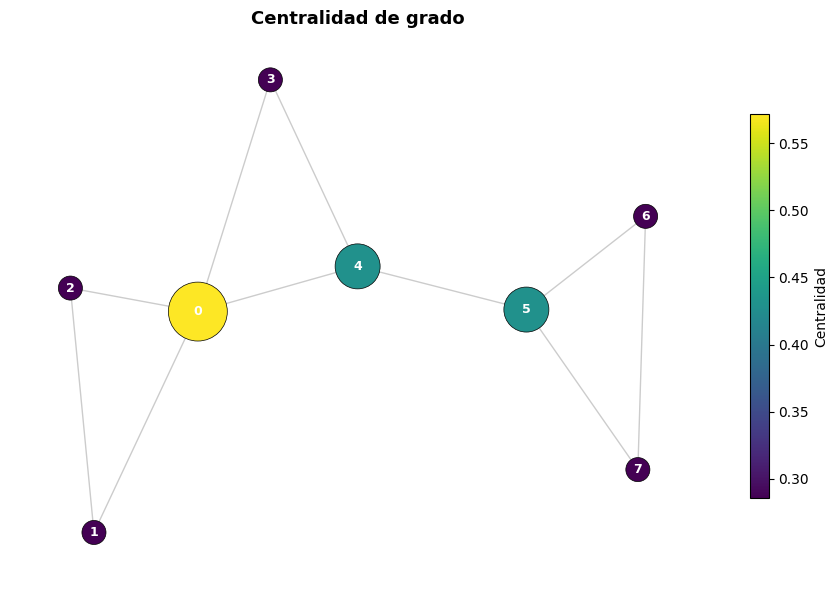

In [5]:
# Visualizar
pos1 = nx.spring_layout(G1, seed=SEED)
fig, ax = plt.subplots(figsize=(9, 6))
dibuja_centralidad(G1, deg_central, "Centralidad de grado", pos=pos1, ax=ax)
plt.tight_layout()
plt.show()

### Pregunta 1

> ¿Qué vértices tienen la mayor centralidad de grado en `G1`? ¿Tiene sentido visualmente? ¿Cuántos vecinos tienen?
> ¿Cuál es el significado del valor de la centralidad de grado normalizad?

*(Escribe tu respuesta abajo.)*



El vértice 0 tiene la mayor centralidad de grado. Siguen los vértices 4 y 5.

 Sí, el vértice 0 está conectado a 4 vecinos distintos, se ve claramente en la gráfica

- Vértice 0: 4 vecinos
- Vértice 4: 3 vecinos
- Vértice 5: 3 vecinos

Normalizar permite comparar la centralidad de grado entre redes de diferentes tamaños.

Vértices con mayor centralidad: 0, 4, 5
Todos los vértices tienen sentido visualmente
0 = 4, 4 = 3, 5 = 3
Nomarlizar el valor de centralida de grado nos permite comparar correctamente con otras gráficas con más vértices

---

## Parte 2 — Centralidad de intermediación (betweenness)

### Idea

Mide qué tan seguido un vértice aparece en las trayectorias más cortas **entre otros pares de vértices**.

$$C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

donde $\sigma_{st}$ es el número de trayectorias mínimas entre $s$ y $t$, y $\sigma_{st}(v)$ cuántas de esas pasan por $v$.

### Interpretación

- **Alto:** el vértice funciona como un **puente** o **cuello de botella**: por él pasa mucha "información" si se mueve por caminos mínimos.
- Captura algo que el grado no ve: un vértice puede tener pocos vecinos y aun así ser crítico si conecta dos comunidades.

### Ejercicio 2.1 

Construye una gráfica con dos triángulos unidos a un vértice central. Ese vértice central tendrá grado bajo pero intermediación alta, es decir que hay casos en que las medidas de grado e intermediación discrepan.

In [6]:
# Gráfica "pajarita":  dos triángulos {A,B,C} y {D,E,F} pegados en el vértice C=D=X
G_bow = nx.Graph()
G_bow.add_edges_from([
    ('A','B'),('A','C'),('B','C'),     # triángulo izquierdo
    ('F','D'),('F','E'),('D','E'),      # triángulo derecho
    ('C','X'),('F','X')                # los triangulos se conectan con el vértice X
])

# Layout manual para que se vea como pajarita
pos_bow = {'A':(-2,0.7),'B':(-2,-0.7),'C':(0,0), 'X':(2,0), 'F':(4,0),'D':(6,0.7),'E':(6,-0.7)}

# Centralidades
grado_bow = nx.degree_centrality(G_bow)
inter_bow = nx.betweenness_centrality(G_bow)

print("Vértice | Grado | C_grado | C_interm")
print("--------|-------|---------|----------")
for v in sorted(G_bow.nodes()):
    print(f"   {v}    |   {G_bow.degree(v)}   |  {grado_bow[v]:.3f}  |  {inter_bow[v]:.3f}")

Vértice | Grado | C_grado | C_interm
--------|-------|---------|----------
   A    |   2   |  0.333  |  0.000
   B    |   2   |  0.333  |  0.000
   C    |   3   |  0.500  |  0.533
   D    |   2   |  0.333  |  0.000
   E    |   2   |  0.333  |  0.000
   F    |   3   |  0.500  |  0.533
   X    |   2   |  0.333  |  0.600


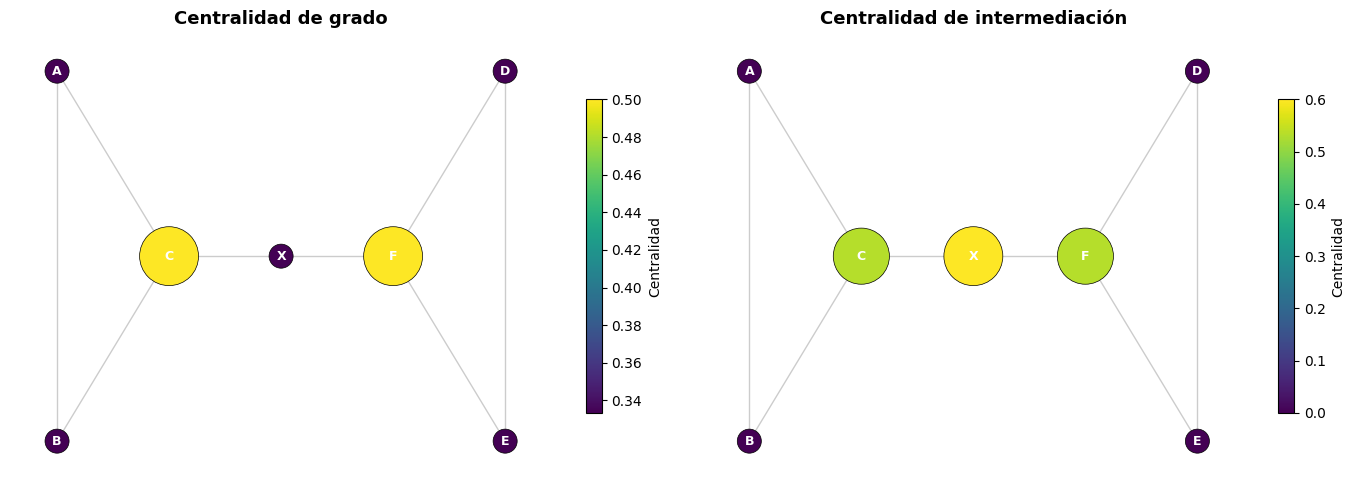

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dibuja_centralidad(G_bow, grado_bow, "Centralidad de grado", pos=pos_bow, ax=axes[0])
dibuja_centralidad(G_bow, inter_bow, "Centralidad de intermediación", pos=pos_bow, ax=axes[1])
plt.tight_layout()
plt.show()

### Pregunta 2

> Compara las dos imágenes. ¿Cuál es la diferencia más notable? ¿Por qué `X` tiene intermediación tan alta si su grado no es el más alto?
> ¿Es una regla general que el grado y la intermediación discrepan?
**Tu respuesta:**

---



En la visualización de grado, los vértices C y F tienen los nodos más grandes.

En la visualización de intermediación, el vértice X es más más grande , mientras que C y F tienen tamaños similares.

X tiene intermediación alta porque es el puente que conecta dos comunidades distintas

No es una regla general, dependerá de cada gráfica, pero pueden coincidir en algunas gráficas específicas.

---

## Parte 3 — Centralidad de cercanía (closeness)

### Idea

Un vértice es central si está **cerca de todos los demás**. Se define como el recíproco de la suma de distancias:

$$C_C(v) = \frac{n-1}{\sum_{u \neq v} d(v, u)}$$

### Interpretación

- **Alto:** el vértice puede alcanzar a todos rápidamente (en pocos saltos en promedio).
- **Limitación grave:** **sólo está definida cuando G es conexa**. Si hay algún vértice inalcanzable desde $v$, entonces $d(v,u) = \infty$ y la suma del denominador es infinita, así que $C_C(v) = 0$. Eso es problemático cuando trabajas con redes desconectadas.

NetworkX maneja esto contando sólo los nodos alcanzables y normalizando por su número (la variante de Wasserman-Faust), pero la idea pura de cercanía tiene este problema.

In [8]:
# Cercanía en la gráfica G1 (de la Parte 1)
cerc_G1 = nx.closeness_centrality(G1)

df_cerc = pd.DataFrame({
    'vértice': list(cerc_G1.keys()),
    'C_cercanía': [round(cerc_G1[v], 3) for v in cerc_G1]
}).sort_values('C_cercanía', ascending=False).reset_index(drop=True)

print(df_cerc)

   vértice  C_cercanía
0        4       0.636
1        0       0.583
2        5       0.538
3        3       0.500
4        2       0.412
5        1       0.412
6        6       0.389
7        7       0.389


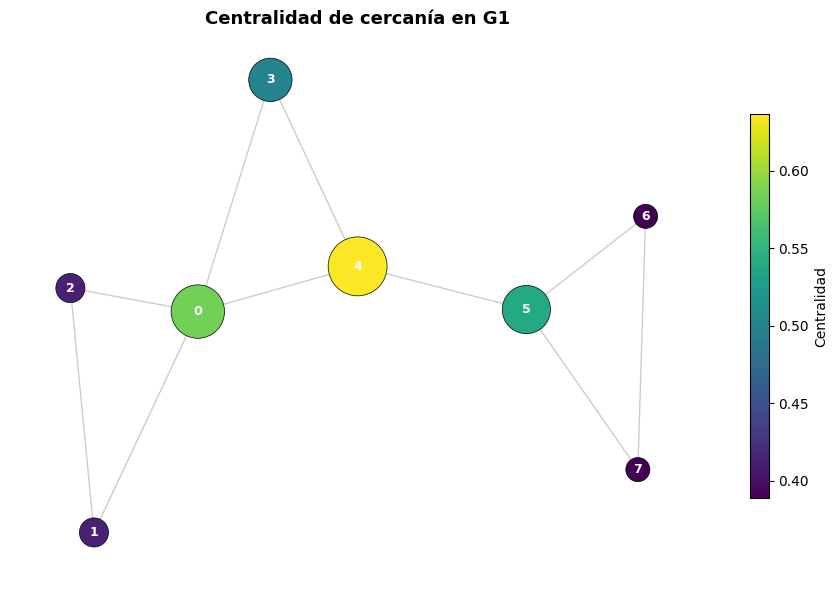

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
dibuja_centralidad(G1, cerc_G1, "Centralidad de cercanía en G1", pos=pos1, ax=ax)
plt.tight_layout()
plt.show()

### Ejercicio 3.1 — ¿Qué pasa en gráficas desconectadas?

Construye una gráfica con dos componentes y observa qué pasa con la cercanía.

In [10]:
# Gráfica desconectada: dos componentes
G_desc = nx.Graph()
# Componente 1: triángulo
G_desc.add_edges_from([(1,2),(2,3),(3,1)])
# Componente 2: camino aislado
G_desc.add_edges_from([(4,5),(5,6),(6,7)])

print("Componentes conexas:", list(nx.connected_components(G_desc)))
print("\nCercanía (con normalización de NetworkX que cuenta solo alcanzables):")
for v, c in nx.closeness_centrality(G_desc).items():
    print(f"   nodo {v}: {c:.3f}")

Componentes conexas: [{1, 2, 3}, {4, 5, 6, 7}]

Cercanía (con normalización de NetworkX que cuenta solo alcanzables):
   nodo 1: 0.333
   nodo 2: 0.333
   nodo 3: 0.333
   nodo 4: 0.250
   nodo 5: 0.375
   nodo 6: 0.375
   nodo 7: 0.250


### Pregunta 3

> Observa los valores. ¿Te parecen comparables entre las dos componentes? El nodo 5 (en medio del camino) y el nodo 2 (en el triángulo) tienen valores similares pese a estar en redes muy distintas. ¿Por qué crees que pasa eso? ¿Te parece justa la comparación?

**Tu respuesta:**

---

Los valores de cercanía no son comparables entre componentes porque se normalizan solo por nodos alcanzables locales, haciendo injusta la comparación.

- Nodo 5 tiene distancia promedio pequeña dentro de su componente de 4 nodos
- Nodos 1, 2, 3 tienen distancia promedio pequeña dentro de su componente de 3 nodos

No es justa la comparación porque:
-Están midiendo en componentes de tamaños diferentes
-Un nodo "central" en una pequeña isla aislada puede parecer más central que un nodo en un grupo grande

In [13]:
# Comparar cercanía y armónica en la gráfica desconectada
cerc_desc = nx.closeness_centrality(G_desc)
arm_desc  = nx.harmonic_centrality(G_desc)

# Normalizar armónica por n-1 (NetworkX la devuelve sin normalizar)
n = G_desc.number_of_nodes()
arm_desc_norm = {v: c/(n-1) for v, c in arm_desc.items()}

df_comp = pd.DataFrame({
    'nodo':       list(G_desc.nodes()),
    'componente': ['triángulo' if v <= 3 else 'camino' for v in G_desc.nodes()],
    'cercanía':   [round(cerc_desc[v], 3) for v in G_desc.nodes()],
    'armónica':   [round(arm_desc_norm[v], 3) for v in G_desc.nodes()]
})
print(df_comp.to_string(index=False))

 nodo componente  cercanía  armónica
    1  triángulo     0.333     0.333
    2  triángulo     0.333     0.333
    3  triángulo     0.333     0.333
    4     camino     0.250     0.306
    5     camino     0.375     0.417
    6     camino     0.375     0.417
    7     camino     0.250     0.306


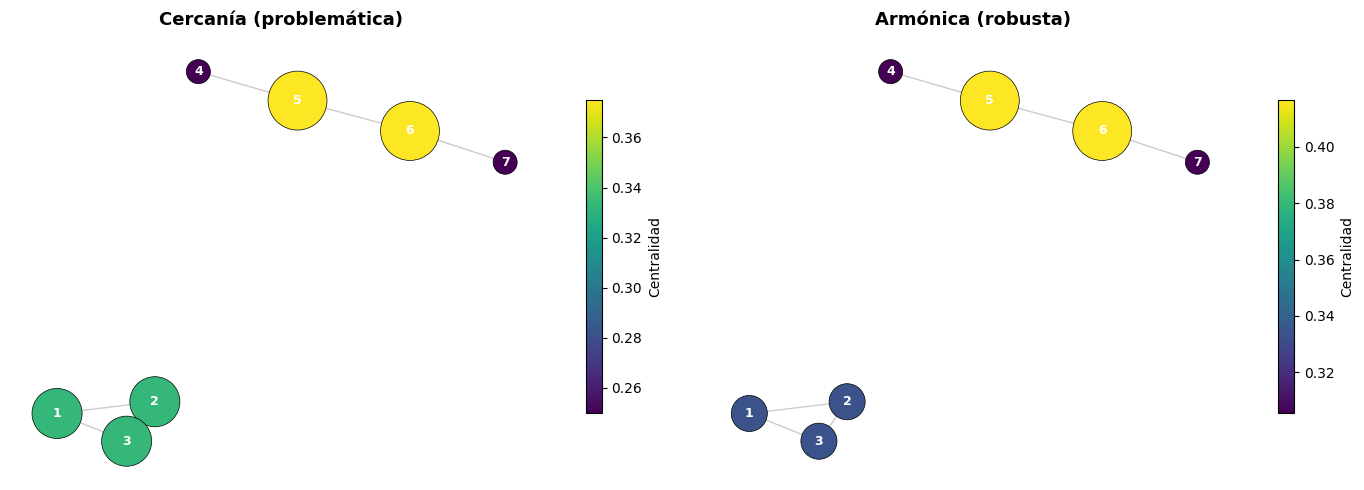

In [14]:
# Visualizar lado a lado en la gráfica desconectada
pos_desc = nx.spring_layout(G_desc, seed=SEED)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dibuja_centralidad(G_desc, cerc_desc,     "Cercanía (problemática)", pos=pos_desc, ax=axes[0])
dibuja_centralidad(G_desc, arm_desc_norm, "Armónica (robusta)",      pos=pos_desc, ax=axes[1])
plt.tight_layout()
plt.show()


Sí, claramente. La armónica muestra diferencias marcadas entre componentes:
-Triángulo: todos iguales
-Centro del camino (5, 6): (mayor)
-Extremos del camino (4, 7): (menor)

La cercanía normalizada es menos clara: los del triángulo y el centro del camino tienen valores similares.

**¿Qué nodos del camino tienen valor armónico mayor?** El centro del camino (nodos 5 y 6) tienen armónica 0.417, mientras que los extremos (4 y 7) tienen 0.306.

**¿Por qué?** Aunque todos están en camino de 4 nodos, los nodos extremos (4 y 7) tienen un solo vecino accesible directamente, mientras que el centro tiene dos.

La armónica es robusta porque funciona en cualquier red desconectada o no

---

## Parte 5 — Las cuatro centralidades, lado a lado

Vamos a aplicar las cuatro centralidades a la misma gráfica `G1` para ver si dan el mismo ranking o no.

In [15]:
# Calcular las cuatro
grado_G1 = nx.degree_centrality(G1)
inter_G1 = nx.betweenness_centrality(G1)
cerc_G1  = nx.closeness_centrality(G1)
arm_G1   = nx.harmonic_centrality(G1)
# Normalizar armónica
n = G1.number_of_nodes()
arm_G1_norm = {v: c/(n-1) for v, c in arm_G1.items()}

df_todas = pd.DataFrame({
    'vértice':       list(G1.nodes()),
    'grado':         [round(grado_G1[v], 3) for v in G1.nodes()],
    'intermediación':[round(inter_G1[v], 3) for v in G1.nodes()],
    'cercanía':      [round(cerc_G1[v], 3)  for v in G1.nodes()],
    'armónica':      [round(arm_G1_norm[v], 3)   for v in G1.nodes()]
})
print(df_todas.to_string(index=False))

 vértice  grado  intermediación  cercanía  armónica
       0  0.571           0.476     0.583     0.738
       1  0.286           0.000     0.412     0.548
       2  0.286           0.000     0.412     0.548
       3  0.286           0.000     0.500     0.595
       4  0.429           0.571     0.636     0.714
       5  0.429           0.476     0.538     0.667
       6  0.286           0.000     0.389     0.524
       7  0.286           0.000     0.389     0.524


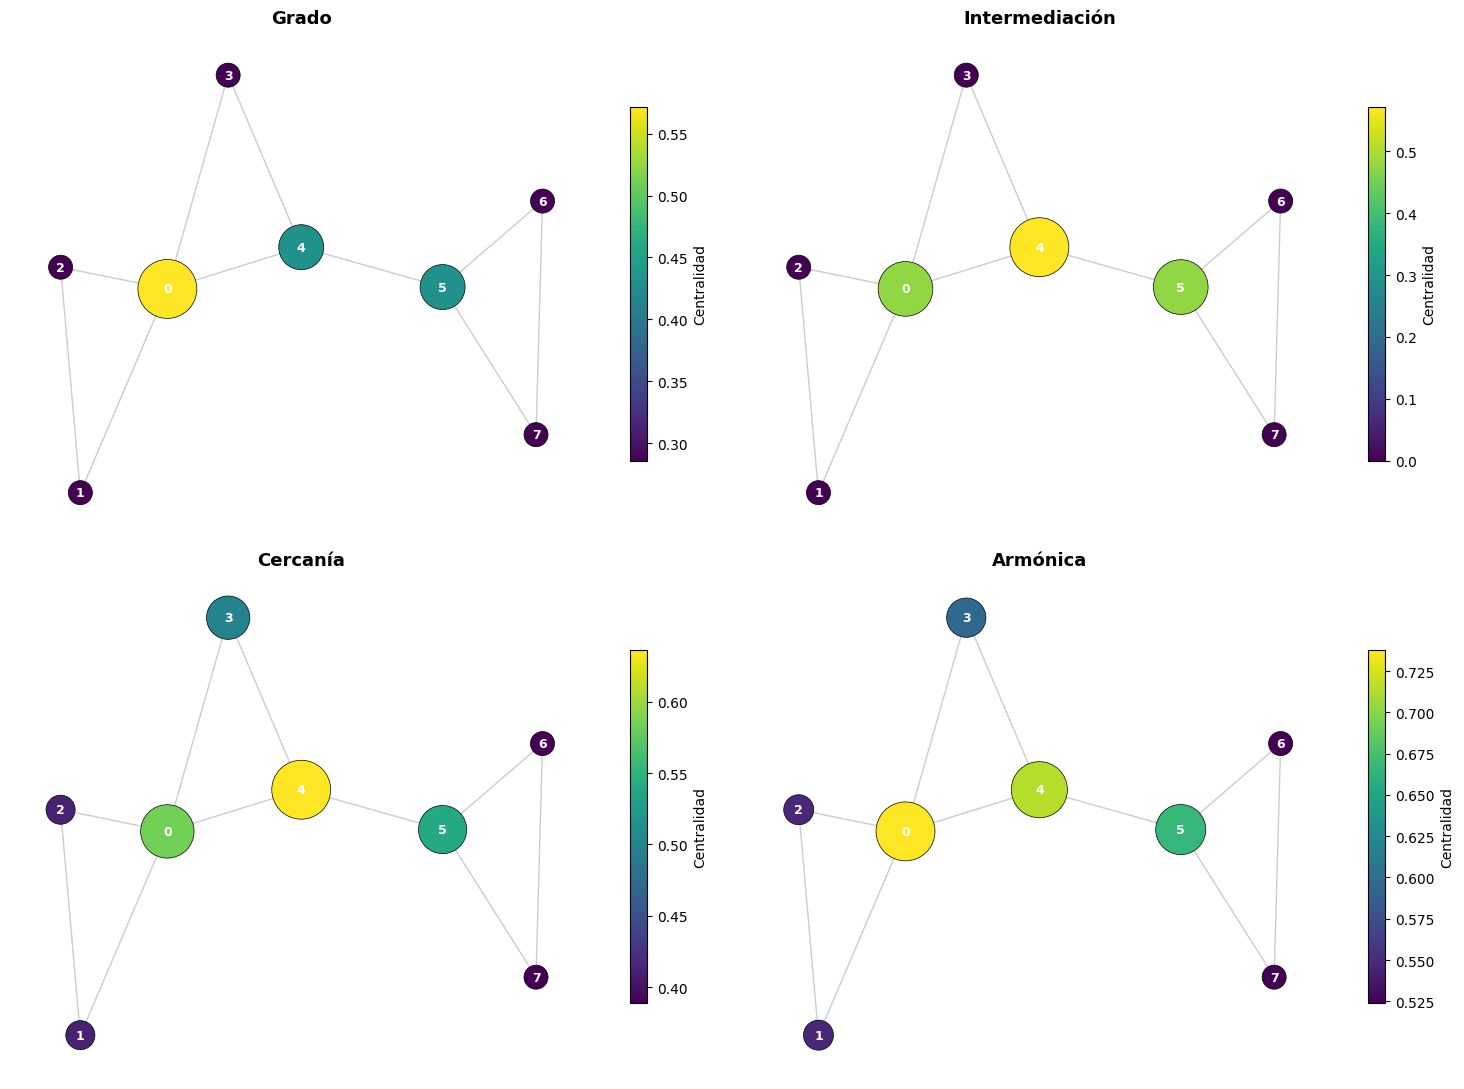

In [16]:
# Visualizar las cuatro
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
dibuja_centralidad(G1, grado_G1,    "Grado",          pos=pos1, ax=axes[0,0])
dibuja_centralidad(G1, inter_G1,    "Intermediación", pos=pos1, ax=axes[0,1])
dibuja_centralidad(G1, cerc_G1,     "Cercanía",       pos=pos1, ax=axes[1,0])
dibuja_centralidad(G1, arm_G1_norm, "Armónica",       pos=pos1, ax=axes[1,1])
plt.tight_layout()
plt.show()


¿Coincide el ganador? No completamente. El vértice 0 gana en grado y armónica, mientras que el vértice 4 gana en intermediación y cercanía.

¿Hay alguna medida que destaca a un vértice que las otras no? 
- La cercanía medida en el vértice 3
- El vértice 4 es particularmente destacado por intermediación y cercanía

Si tuvieras que eliminar un vértice para desconectar la red en dos partes, ¿cuál escogerías?
Elegiría el **vértice 4**, porque:
- Porque el vértice 4 es el puente principal entre dos grupos
La intermediación lo identifica como puente, entonces utilizaría esta medida




---

## Parte 6 — Aplicación a una red real: el club de karate de Zachary

Wayne Zachary observó durante 3 años un club de karate de 34 miembros. Documentó quién interactuaba con quién fuera del entrenamiento. Eventualmente, **el club se dividió en dos** por un conflicto entre el instructor (nodo 0, "Mr. Hi") y el administrador (nodo 33, "Officer").

La red amistades del clin Zachary en una de las más usadas en análisis de redes complejas para probar algoritmos. Lo bonito: las centralidades **predicen** quién fue líder de cada facción.

In [17]:
# Cargar la red
K = nx.karate_club_graph()
print(f"Nodos:    {K.number_of_nodes()}")
print(f"Aristas:  {K.number_of_edges()}")
print(f"Conexa:   {nx.is_connected(K)}")
print(f"Diámetro: {nx.diameter(K)}")

Nodos:    34
Aristas:  78
Conexa:   True
Diámetro: 5


In [18]:
# Calcular las cuatro centralidades
g_K = nx.degree_centrality(K)
i_K = nx.betweenness_centrality(K)
c_K = nx.closeness_centrality(K)
a_K = nx.harmonic_centrality(K)
nK = K.number_of_nodes()
a_K_norm = {v: c/(nK-1) for v, c in a_K.items()}

# Top 5 por cada medida
def top5(cent, nombre):
    ordenado = sorted(cent.items(), key=lambda x: -x[1])[:5]
    print(f"\n{nombre}:")
    for v, val in ordenado:
        print(f"  nodo {v:2d}  →  {val:.3f}")

top5(g_K,      "Grado")
top5(i_K,      "Intermediación")
top5(c_K,      "Cercanía")
top5(a_K_norm, "Armónica")


Grado:
  nodo 33  →  0.515
  nodo  0  →  0.485
  nodo 32  →  0.364
  nodo  2  →  0.303
  nodo  1  →  0.273

Intermediación:
  nodo  0  →  0.438
  nodo 33  →  0.304
  nodo 32  →  0.145
  nodo  2  →  0.144
  nodo 31  →  0.138

Cercanía:
  nodo  0  →  0.569
  nodo  2  →  0.559
  nodo 33  →  0.550
  nodo 31  →  0.541
  nodo  8  →  0.516

Armónica:
  nodo 33  →  0.705
  nodo  0  →  0.702
  nodo  2  →  0.636
  nodo 32  →  0.634
  nodo 31  →  0.586


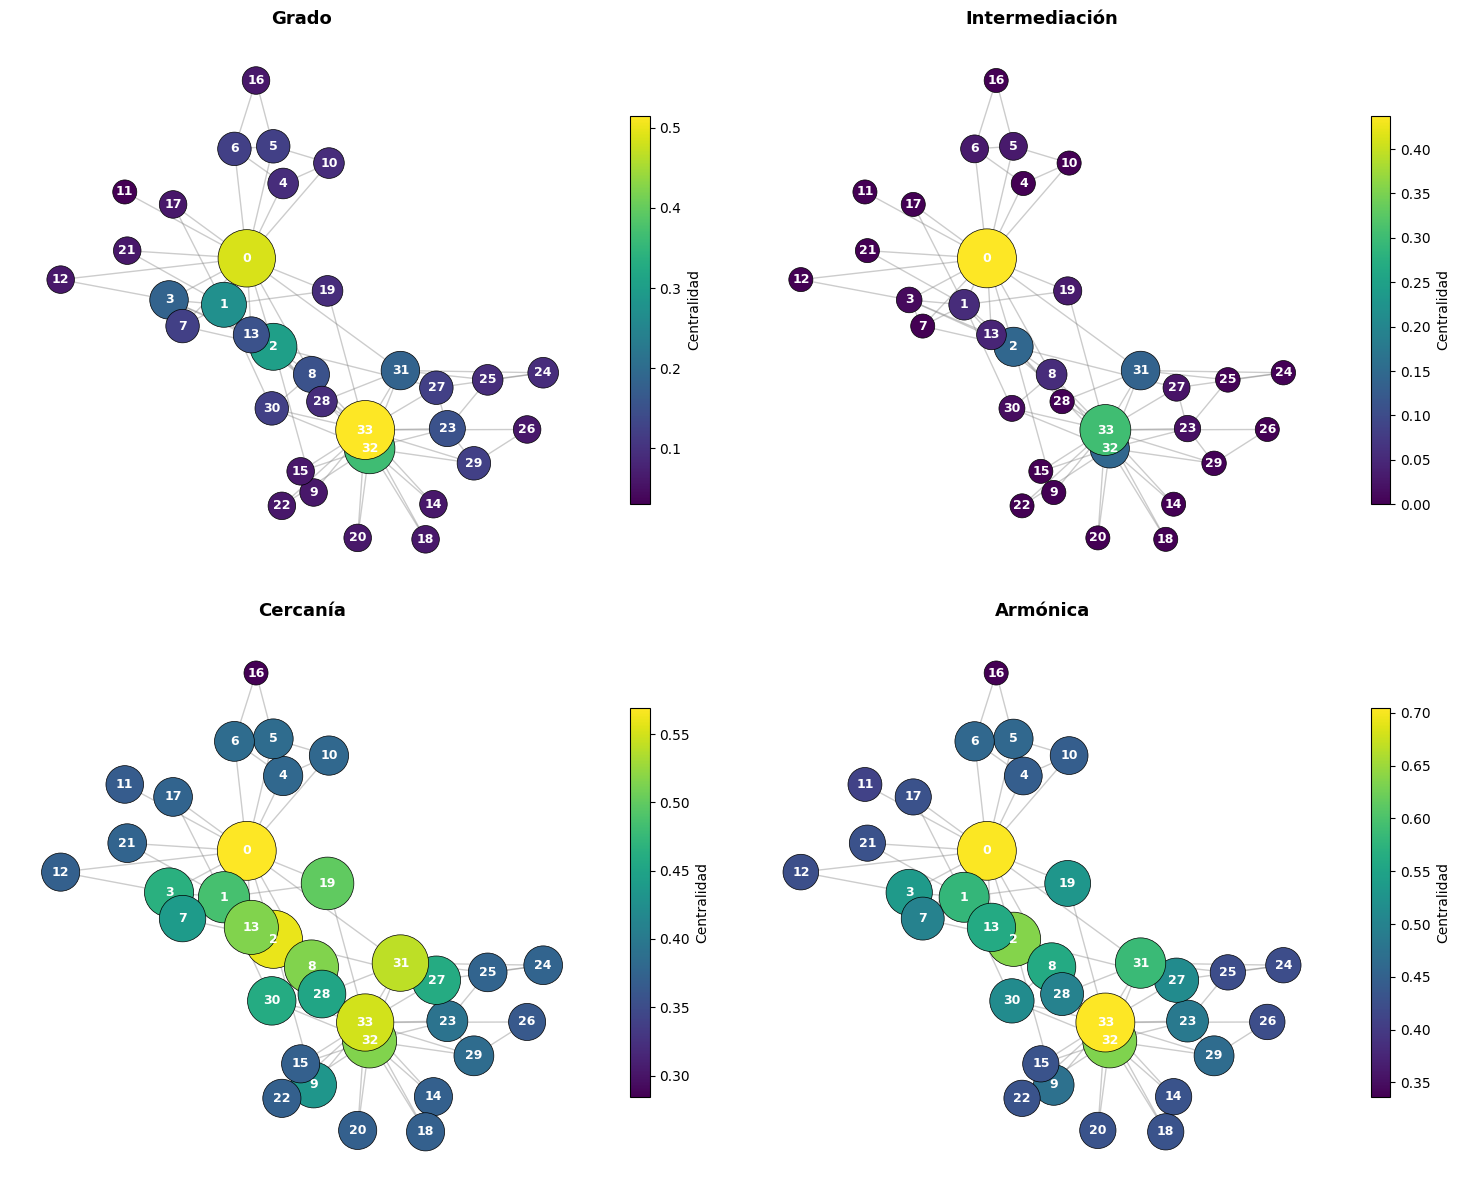

In [19]:
# Visualizar las cuatro en el karate club
pos_K = nx.spring_layout(K, seed=SEED)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
dibuja_centralidad(K, g_K,      "Grado",          pos=pos_K, ax=axes[0,0])
dibuja_centralidad(K, i_K,      "Intermediación", pos=pos_K, ax=axes[0,1])
dibuja_centralidad(K, c_K,      "Cercanía",       pos=pos_K, ax=axes[1,0])
dibuja_centralidad(K, a_K_norm, "Armónica",       pos=pos_K, ax=axes[1,1])
plt.tight_layout()
plt.show()

### Pregunta 6

> Los nodos 0 (Mr. Hi, el instructor) y 33 (Officer, el administrador) son los dos líderes del conflicto.
>
> - ¿Aparecen ambos en el top 5 de alguna medida? ¿De cuáles?
> - ¿Hay algún nodo que destaca en intermediación pero no en grado? Ese nodo es probablemente un "puente" entre las facciones — ¿quién es?
> - El club Zachary se dividio en dos facciones, si tuvieras que predecir a qué facción se uniría cada miembro con sólo mirar centralidades, ¿cuál centralidad usarías y de qué manera?

**Tu respuesta:**

---


¿Aparecen ambos líderes en el top 5?
Sí, ambos aparecen:
- Nodo 0 (Mr. Hi, instructor): top 2 en grado, top 1 en intermediación y cercanía, top 2 en armónica
- Nodo 33 (Officer, administrador): top 1 en grado, top 2 en intermediación, top 3 en cercanía, top 1 en armónica

¿Hay algún nodo que destaca en intermediación pero no en grado?
Sí, el nodo 0, en intermediación aparece como el más importante, pero en grado no.

El nodo 0 tiene intermediación considerablemente más alta que el nodo 33, pese a tener grado ligeramente menor. Esto nos puede decir que Mr. Hi es un puente crítico que conecta comunidades.

¿Quién es el puente predicho? El nodo 0 (Mr. Hi) es el puente más importante por intermediación.
Cercanía porque mide quién puede llegar rápido a todos.

---

## Parte 7 — Ejercicio integrador

Construye **tu propia gráfica** que cumpla las siguientes condiciones:

1. Tiene al menos 10 vértices.
2. Tiene un vértice que es **el más central por grado pero no por intermediación**.
3. Tiene un vértice que es **el más central por intermediación pero no por grado**.

Sugerencia: combina un vértice *"hub"* (nodo con grado alto) con vértice *"puente"* entre dos facciones de la red.

Nodos:    12
Aristas:  27


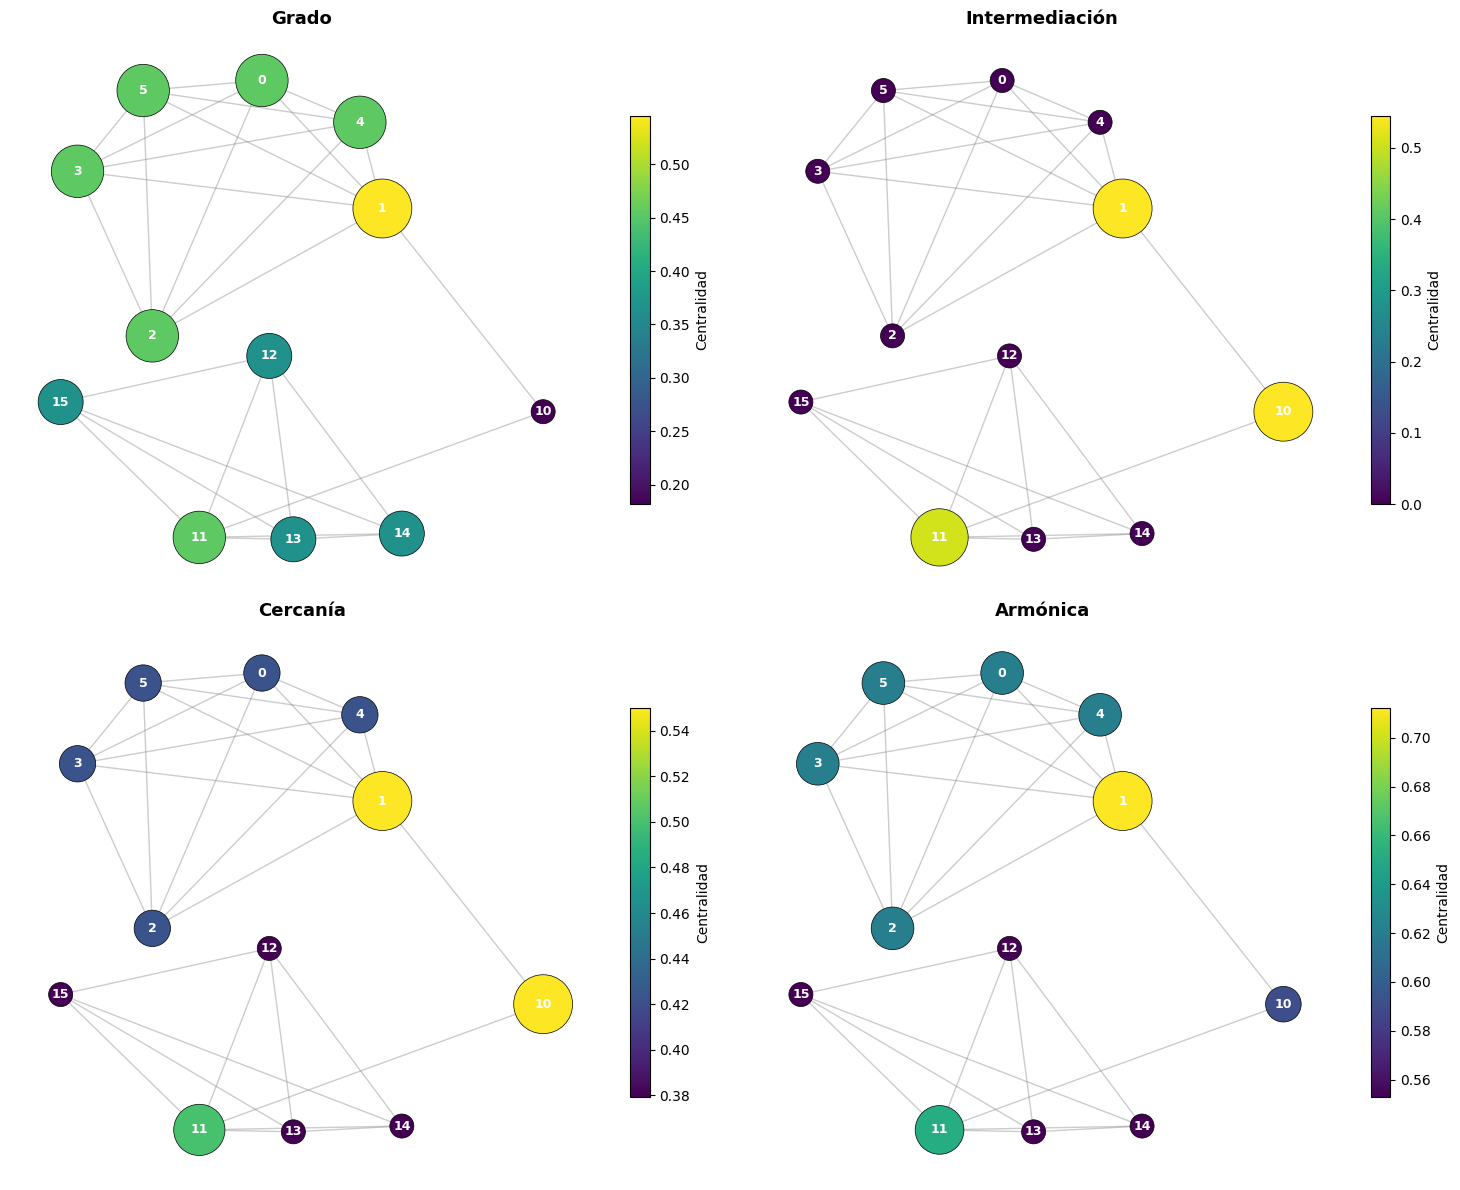

In [14]:

G_mia = nx.Graph()
#Comunidad izquierda de 6 nodos {0,1,2,3,4,5}
for i in range(6):
    for j in range(i+1, 6):
        G_mia.add_edge(i, j)

#Nodo puente (10) conecta con nodo 1
G_mia.add_edge(1, 10)

#Comunidad derecha de 5 nodos {11,12,13,14,15}
for i in range(11, 16):
    for j in range(i+1, 16):
        G_mia.add_edge(i, j)

# Conectar el puente con la comunidad derecha
G_mia.add_edge(10, 11)

print(f"Nodos:    {G_mia.number_of_nodes()}")
print(f"Aristas:  {G_mia.number_of_edges()}")

# Calcular todas las medidas
grado_mia = nx.degree_centrality(G_mia)
inter_mia = nx.betweenness_centrality(G_mia)
cerc_mia = nx.closeness_centrality(G_mia)
arm_mia = nx.harmonic_centrality(G_mia)
n_mia = G_mia.number_of_nodes()
arm_mia_norm = {v: c/(n_mia-1) for v, c in arm_mia.items()}


# Visualizar las cuatro medidas en la gráfica
pos_mia = nx.spring_layout(G_mia, seed=SEED, k=2)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
dibuja_centralidad(G_mia, grado_mia,    "Grado",          pos=pos_mia, ax=axes[0,0])
dibuja_centralidad(G_mia, inter_mia,    "Intermediación", pos=pos_mia, ax=axes[0,1])
dibuja_centralidad(G_mia, cerc_mia,     "Cercanía",       pos=pos_mia, ax=axes[1,0])
dibuja_centralidad(G_mia, arm_mia_norm, "Armónica",       pos=pos_mia, ax=axes[1,1])
plt.tight_layout()
plt.show()



### Reporta:

**1. Lista de aristas de tu gráfica:**


Comunidad izquierda:
  (0,1), (0,2), (0,3), (0,4), (0,5)
  (1,2), (1,3), (1,4), (1,5)
  (2,3), (2,4), (2,5)
  (3,4), (3,5)
  (4,5)
  
Comunidad derecha:
  (11,12), (11,13), (11,14), (11,15)
  (12,13), (12,14), (12,15)
  (13,14), (13,15)
  (14,15)

Conexión puente:
  (1, 10)      nodo 1 al puente
  (10, 11)     puente a la comunidad derecha


Total: 12 vértices, 27 aristas

**2. Qué vértice gana en cada medida:**

- **Grado** | Nodo 1 
- **Intermediación** | Nodo 10 
- **Cercanía** | Nodo 10 
- **Armónica** | Nodo 0

**3. Explicación de por qué cumple las condiciones:**

- Tiene más de 10 vértices 

- Se cumple con varios nodos de cada comunidad, por ejemplo 2, 4, 5, 13, 14, que tiene centralidad de grado alta, pero baja de intermediación.

- El nodo 10 tiene centralidad por intermediacíon alta por conectar dos comunidades, pero baja por tener solo 2 vecinos.

---

## Resumen

| Medida | Fórmula | Captura | Robusta a desconexión |
|---|---|---|---|
| **Grado** | $\deg(v)/(n-1)$ | Popularidad local | Sí |
| **Intermediación** | $\sum_{s,t} \sigma_{st}(v)/\sigma_{st}$ | Función de puente | Sí |
| **Cercanía** | $(n-1)/\sum_u d(v,u)$ | Distancia promedio | **No** |
| **Armónica** | $\sum_u 1/d(v,u) \,/\, (n-1)$ | Como cercanía | **Sí** |

### Para tu reporte

Entrega este notebook ejecutado, con todas las preguntas respondidas y el ejercicio integrador completo.

### Lecturas recomendadas

- *The Atlas for*. Cap 4 (centrality).  
- Newman, M. E. J. *Networks: An Introduction*. Cap. 7 (centralidad).
- Boldi, P. & Vigna, S. (2014). *Axioms for Centrality*. Internet Mathematics 10:222-262 — el paper que defiende la centralidad armónica.
